In [1]:
# Data handling
import pandas as pd
import numpy as np

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLP resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load dataset

df = pd.read_csv("Stanley_Cup.csv")

# Display first rows

df.head()

,Name,Year,Teams,Total Posts,Total Comments,Total Scores,Avg Sentiment (TextBlob),Avg Sentiment (Vader),Viewers (Millions)
0,2012 Stanley Cup Finals Game 1,2012,"Los Angeles Kings, New Jersey Devils",4,28,27,0.033789,0.106500,2.979
1,2012 Stanley Cup Finals Game 2,2012,"Los Angeles Kings, New Jersey Devils",5,30,12,-0.108750,-0.016500,2.900
2,2012 Stanley Cup Finals Game 3,2012,"Los Angeles Kings, New Jersey Devils",8,29,34,0.017533,0.231513,2.900
3,2012 Stanley Cup Finals Game 4,2012,"Los Angeles Kings, New Jersey Devils",9,20,27,0.258109,0.474644,1.743
4,2012 Stanley Cup Finals Game 5,2012,"Los Angeles Kings, New Jersey Devils",7,13,22,-0.109521,0.160457,2.069


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      76 non-null     str    
 1   Year                      76 non-null     int64  
 2   Teams                     76 non-null     str    
 3   Total Posts               76 non-null     int64  
 4   Total Comments            76 non-null     int64  
 5   Total Scores              76 non-null     int64  
 6   Avg Sentiment (TextBlob)  76 non-null     float64
 7   Avg Sentiment (Vader)     76 non-null     float64
 8   Viewers (Millions)        76 non-null     float64
dtypes: float64(3), int64(4), str(2)
memory usage: 10.4 KB


In [4]:
# Find text columns

text_columns = df.select_dtypes(include=['object']).columns

text_columns

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_64480/3645602333.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


Index(['Name', 'Teams'], dtype='str')

In [5]:
# Combine all text columns into one NLP column

df['combined_text'] = df[text_columns].astype(str).agg(' '.join, axis=1)

df[['combined_text']].head()

,combined_text
0,2012 Stanley Cup Finals Game 1 Los Angeles Kin...
1,2012 Stanley Cup Finals Game 2 Los Angeles Kin...
2,2012 Stanley Cup Finals Game 3 Los Angeles Kin...
3,2012 Stanley Cup Finals Game 4 Los Angeles Kin...
4,2012 Stanley Cup Finals Game 5 Los Angeles Kin...


In [6]:
# Stopwords and Lemmatization

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


def clean_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove special characters
    text = re.sub('[^a-zA-Z]', ' ', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)



df['clean_text'] = df['combined_text'].apply(clean_text)

df[['clean_text']].head()

,clean_text
0,stanley cup final game los angeles king new je...
1,stanley cup final game los angeles king new je...
2,stanley cup final game los angeles king new je...
3,stanley cup final game los angeles king new je...
4,stanley cup final game los angeles king new je...


In [7]:
tfidf = TfidfVectorizer(
    max_features=5000
)


X = tfidf.fit_transform(df['clean_text'])


X.shape

(76, 44)

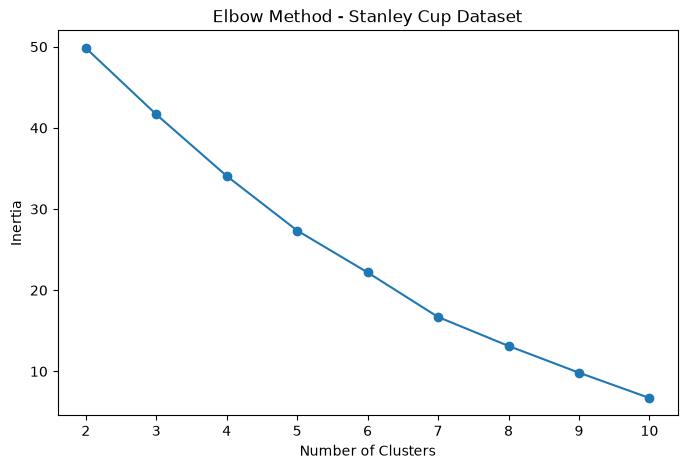

In [8]:
inertia = []

for k in range(2,11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    inertia.append(kmeans.inertia_)



plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method - Stanley Cup Dataset")

plt.show()

In [9]:
df.to_csv(
    "Stanley_Cup_KMeans_NLP_Output.csv",
    index=False
)